# Análisis de Vulnerabilidad y Violencia contra la Mujer en Distritos de Lima

Este notebook presenta un análisis integral de la situación de vulnerabilidad y violencia contra la mujer en los distritos de Lima. El objetivo principal es identificar patrones y agrupar distritos con características similares para facilitar la comprensión y el diseño de políticas públicas focalizadas.

El proceso incluye las siguientes etapas:
1.  **Carga y Preprocesamiento de Datos:** Integración de diversas fuentes de datos.
2.  **Ingeniería de Características:** Creación de indicadores clave como la Tasa de Violencia contra la Mujer (TVM) y el Índice de Vulnerabilidad.
3.  **Análisis Exploratorio de Datos (EDA):** Visualizaciones geográficas y análisis de correlaciones para entender la distribución y las relaciones entre las variables.
4.  **Reducción de Dimensionalidad:** Aplicación de PCA y NMF para simplificar la complejidad de los datos y extraer componentes latentes que representen las dimensiones principales de la vulnerabilidad.
5.  **Clustering:** Agrupación de distritos utilizando K-Means y Clustering Jerárquico para identificar perfiles distintivos y comparar los resultados de diferentes algoritmos.

Este análisis se enfoca en los distritos de Lima para el año 2025, utilizando datos proyectados y procesados.

###1. Carga y Preprocesamiento de Datos

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
denuncias_modalidad = pd.read_csv('../data/processed/denuncias_modalidad.csv')
proporciones_mujeres = pd.read_csv('../data/processed/proporciones_distritales_mujeres_hogares.csv')
poblacion_distrital = pd.read_csv('../data/processed/poblacion_por_distrito.csv')

In [19]:
proporciones_mujeres = proporciones_mujeres.iloc[:,1:]

In [20]:
## filtrar por año 2025

denuncias_2025 = denuncias_modalidad[denuncias_modalidad['anio'] == 2025]
proporciones_mujeres_2025 = proporciones_mujeres
poblacion_distrital_2025 = poblacion_distrital[poblacion_distrital['anio'] == 2025]

In [21]:
base_final = denuncias_2025.merge(proporciones_mujeres_2025, on='ubigeo', how='inner')
base_final = base_final.merge(poblacion_distrital_2025, on='ubigeo', how='inner')

In [22]:
base_final.drop(columns=['departamento_y', 'provincia_y', 'distrito_y', 'anio_y'], inplace=True)
base_final.rename(columns={'departamento_x': 'departamento', 'provincia_x': 'provincia', 'distrito_x': 'distrito', 'anio_x': 'anio'}, inplace=True)

In [23]:
base_final.describe()

,anio,ubigeo,amenaza_grave,coaccion_grave,maltrato_sin_lesion,violencia_economica_o_patrimonial,violencia_fisica,violencia_fisica_y_psicologica,violencia_psicologica,violencia_sexual,...,prop_edu_basica,prop_alfabetizacion_funcional,prop_lengua_materna_nativa,prop_tic_uso_internet,prop_tic_celular_propio,prop_salud_enfermedad_cronica,prop_tiene_limitacion,prop_tiene_seguro,media_edad,población
count,1131.0,1131.000000,1131.000000,1131.000000,1131.0,1131.000000,1131.000000,1131.0,1131.000000,1131.000000,...,1131.000000,1131.000000,1131.000000,1112.000000,1131.000000,1131.000000,1131.000000,1131.000000,1131.000000,1.131000e+03
mean,2025.0,115747.170645,0.223696,0.041556,0.0,8.761273,93.847038,0.0,155.926614,2.143236,...,0.664334,0.862817,0.319650,0.735433,0.826227,0.610332,0.081492,0.952829,48.691335,2.877127e+04
std,0.0,67783.635245,2.694210,0.250746,0.0,42.593090,255.636600,0.0,469.789020,8.479585,...,0.184579,0.142456,0.367752,0.264244,0.161730,0.180176,0.099986,0.074101,6.878287,7.669691e+04
min,2025.0,10101.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.178518,0.000000,0.000000,0.000000,0.000000,0.000000,0.200000,29.333333,2.090000e+02
25%,2025.0,55604.500000,0.000000,0.000000,0.0,0.000000,4.000000,0.0,4.000000,0.000000,...,0.539751,0.803027,0.000000,0.611393,0.755951,0.500000,0.000000,0.924046,43.790311,3.454500e+03
50%,2025.0,120116.000000,0.000000,0.000000,0.0,0.000000,15.000000,0.0,22.000000,0.000000,...,0.664475,0.907195,0.127456,0.812602,0.872601,0.613279,0.053614,1.000000,47.576771,8.128000e+03
75%,2025.0,160403.000000,0.000000,0.000000,0.0,2.000000,62.500000,0.0,86.500000,1.000000,...,0.798917,0.968070,0.635478,0.937788,0.936820,0.734883,0.123852,1.000000,53.007294,2.076400e+04
max,2025.0,250401.000000,80.000000,3.000000,0.0,553.000000,3337.000000,0.0,5923.000000,105.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.600000,1.000000,74.750000,1.282635e+06


In [24]:
base_final.shape

(1131, 38)

### 3. Ingeniería de Características

En esta sección, se construyen dos indicadores clave a partir de los datos brutos para capturar las dimensiones centrales del análisis:

1.  **Tasa de Violencia contra la Mujer (TVM):** Este indicador mide la incidencia de denuncias de violencia por cada 1000 habitantes en un distrito, proporcionando una métrica estandarizada de la prevalencia de violencia.
2.  **Índice de Vulnerabilidad:** Este índice compuesto agrupa varias métricas relacionadas con las Necesidades Básicas Insatisfechas (NBI) y la falta de acceso a servicios esenciales, ofreciendo una medida holística de la vulnerabilidad socioeconómica de cada distrito.

**Tasa de Violencia contra la Mujer (TVM)**

In [25]:
base_final['TVM'] = base_final['total'] / base_final['población'] * 1000

**Índice de Vulnerabilidad**



In [26]:
base_final.columns

Index(['anio', 'ubigeo', 'departamento', 'provincia', 'distrito',
       'amenaza_grave', 'coaccion_grave', 'maltrato_sin_lesion',
       'violencia_economica_o_patrimonial', 'violencia_fisica',
       'violencia_fisica_y_psicologica', 'violencia_psicologica',
       'violencia_sexual', 'total', 'prop_viv_tipo', 'prop_tic_celular',
       'prop_tic_internet', 'prop_agua_todos_dias', 'prop_serv_electricidad',
       'prop_nbi_vivienda', 'prop_nbi_hacinamiento', 'prop_nbi_sshh',
       'prop_nbi_educacion', 'prop_nbi_dependencia', 'prop_es_jefe',
       'prop_es_mujer', 'prop_en_pareja', 'prop_edu_superior',
       'prop_edu_basica', 'prop_alfabetizacion_funcional',
       'prop_lengua_materna_nativa', 'prop_tic_uso_internet',
       'prop_tic_celular_propio', 'prop_salud_enfermedad_cronica',
       'prop_tiene_limitacion', 'prop_tiene_seguro', 'media_edad', 'población',
       'TVM'],
      dtype='str')

In [27]:
base_final["prop_sin_agua_diaria"] = 1 - base_final["prop_agua_todos_dias"]
base_final["prop_sin_electricidad"] = 1 - base_final["prop_serv_electricidad"]
base_final["prop_sin_internet"] = 1 - base_final["prop_tic_internet"]

variables_vulnerabilidad = [
    "prop_nbi_vivienda",
    "prop_nbi_hacinamiento",
    "prop_nbi_sshh",
    "prop_nbi_educacion",
    "prop_nbi_dependencia",
    "prop_sin_agua_diaria",
    "prop_sin_electricidad",
    "prop_sin_internet"
]

base_final["indice_vulnerabilidad"] = (
    base_final[variables_vulnerabilidad].mean(axis=1)
)

base_final['indice_vulnerabilidad'] = base_final['indice_vulnerabilidad'].fillna(0).astype('float64')

base_final.head()

,anio,ubigeo,departamento,provincia,distrito,amenaza_grave,coaccion_grave,maltrato_sin_lesion,violencia_economica_o_patrimonial,violencia_fisica,...,prop_salud_enfermedad_cronica,prop_tiene_limitacion,prop_tiene_seguro,media_edad,población,TVM,prop_sin_agua_diaria,prop_sin_electricidad,prop_sin_internet,indice_vulnerabilidad
0,2025,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,0,0,0,62,257,...,0.679256,0.112473,0.980843,47.066860,41843.0,20.122840,0.268047,0.037552,0.072248,0.057064
1,2025,10104,AMAZONAS,CHACHAPOYAS,CHETO,0,0,0,0,0,...,0.500000,0.000000,1.000000,47.250000,716.0,2.793296,0.000000,0.000000,0.000000,0.000000
2,2025,10106,AMAZONAS,CHACHAPOYAS,CHUQUIBAMBA,0,0,0,0,3,...,0.714286,0.142857,1.000000,59.285714,1872.0,3.739316,0.000000,0.250000,0.250000,0.062500
3,2025,10109,AMAZONAS,CHACHAPOYAS,LA JALCA,0,0,0,0,15,...,0.579753,0.000000,1.000000,46.969642,3279.0,14.028667,0.000000,0.067488,0.134975,0.082820
4,2025,10110,AMAZONAS,CHACHAPOYAS,LEIMEBAMBA,0,0,0,1,2,...,0.830911,0.027976,1.000000,52.438633,3716.0,2.421959,0.000000,0.162325,0.027054,0.043963


In [28]:
base_final.drop(columns = ['prop_sin_agua_diaria', 'prop_sin_electricidad', 'prop_sin_internet'], inplace=True)

In [29]:
base_final.indice_vulnerabilidad.describe()

count    1131.000000
mean        0.069281
std         0.064633
min         0.000000
25%         0.023138
50%         0.049949
75%         0.096962
max         0.478224
Name: indice_vulnerabilidad, dtype: float64

## 4. Análisis Exploratorio de Datos (EDA)

El análisis exploratorio de datos es fundamental para comprender la distribución de las variables, identificar patrones geográficos y evaluar las relaciones entre las diferentes dimensiones. Esta sección se divide en:

*   **Visualizaciones Geográficas:** Mapas de Perú y Lima para observar la distribución espacial de la TVM y los tipos de violencia.
*   **Análisis Descriptivo:** Estadísticas resumidas y gráficos de dispersión para entender las características de los distritos de Lima.
*   **Análisis de Correlaciones:** Evaluación de las relaciones lineales entre las variables para identificar redundancias y preparar los datos para la reducción de dimensionalidad.

### 4.1. Visualización Geográfica

In [30]:
# importar libreria
import geopandas as gpd

In [31]:
# correción de nombres de departamentos
base_final['departamento'] = base_final['departamento'].replace({'LIMA METROPOLITANA': 'LIMA',
                                                             'REGION LIMA': 'LIMA',
                                                             'PROV. CONST. DEL CALLAO': 'LIMA',})

In [32]:
ruta_departamentos = "../data/raw/DEPARTAMENTO.gpkg"

# Listar layers
layers = gpd.list_layers(ruta_departamentos)
print(layers)

# cargar el layer de departamentos
gdf = gpd.read_file(ruta_departamentos, layer=layers.iloc[0]['name'])


           name geometry_type
0  DEPARTAMENTO  MultiPolygon


#### Gráficos para Perú

In [33]:
peru = base_final.groupby("departamento").agg(TVM = ("TVM", "mean"),
                                            violencia_fisica = ("violencia_fisica", "sum"),
                                            violencia_psicologica = ("violencia_psicologica", "sum"),
                                            violencia_sexual = ("violencia_sexual", "sum"),
                                            violencia_economica_o_patrimonial = ("violencia_economica_o_patrimonial", "sum")
                                            ).reset_index()

peru.head()

,departamento,TVM,violencia_fisica,violencia_psicologica,violencia_sexual,violencia_economica_o_patrimonial
0,AMAZONAS,5.969888,1162,1860,15,92
1,ANCASH,5.963181,3796,6661,39,403
2,APURIMAC,8.333669,2391,2681,15,70
3,AREQUIPA,11.230408,6972,11471,220,244
4,AYACUCHO,6.696081,2298,3795,8,119


In [34]:
peru_georreferenciado = peru.merge(
    gdf,
    left_on="departamento",
    right_on="nombdep",
    how="inner"
)

In [35]:
peru_georreferenciado_gdf = gpd.GeoDataFrame(
    peru_georreferenciado,
    geometry="geometry"
)

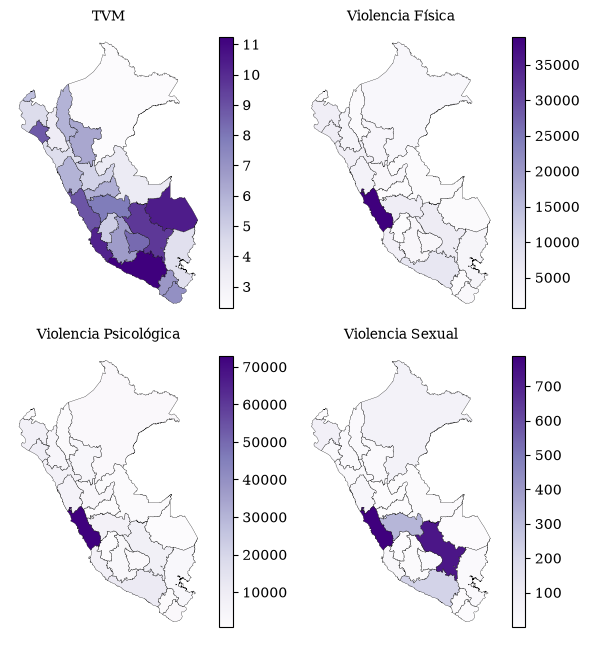

In [36]:
import matplotlib.pyplot as plt

# parámetros globales para formato IEEE
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.titlesize': 10,
    'figure.autolayout': True,
    'savefig.dpi':      300,
    'savefig.bbox':     'tight',
})

# variables y titulos
variables = ['TVM', 'violencia_fisica', 'violencia_psicologica', 'violencia_sexual']
titulos = ['TVM', 'Violencia Física', 'Violencia Psicológica', 'Violencia Sexual']


fig, axes = plt.subplots(2, 2, figsize=(6, 8))
axes = axes.flatten() # Aplanar para iterar fácilmente

# graficar
for ax, var, title in zip(axes, variables, titulos):
    peru_georreferenciado_gdf.plot(
        column=var,
        ax=ax,
        legend=True,
        cmap='Purples',
        edgecolor='black',
        linewidth=0.2,
        legend_kwds={
            'orientation': "vertical",
            'shrink': 0.6,
            'pad': 0.05
        }
    )

    ax.set_title(title)
    ax.set_axis_off()

# guardar
plt.savefig("mapa_violencia_general.png", dpi=300, bbox_inches='tight')

plt.show()

#### Gráficos para Lima

In [37]:
lima = base_final[base_final['provincia'] == 'LIMA'][['distrito', 'TVM', 'violencia_fisica', 'violencia_psicologica', 'violencia_sexual']].reset_index(drop=True)
lima.head()

,distrito,TVM,violencia_fisica,violencia_psicologica,violencia_sexual
0,LIMA,26.432846,2213,4340,78
1,ANCON,5.614431,235,310,6
2,ATE,9.725400,2464,4466,9
3,BARRANCO,13.301446,135,351,0
4,BREÑA,12.123258,344,719,8


In [38]:
ruta_distrito = "../data/raw/DISTRITO.gpkg"

# Listar los layers
layers = gpd.list_layers(ruta_distrito)
print(layers)

# Cargar layer de distritos
gdf = gpd.read_file(ruta_distrito, layer=layers.iloc[0]['name'])

# Filtrar donde la columna 'nombprov' sea igual a 'LIMA'
lima_gdf = gdf[gdf['nombprov'] == 'LIMA'].copy()

       name geometry_type
0  DISTRITO  MultiPolygon


In [39]:
lima_georreferenciado = lima.merge(
    lima_gdf,
    left_on="distrito",
    right_on="nombdist",
    how="inner"
)

In [40]:
lima_georreferenciado_gdf = gpd.GeoDataFrame(
    lima_georreferenciado,
    geometry="geometry"
)

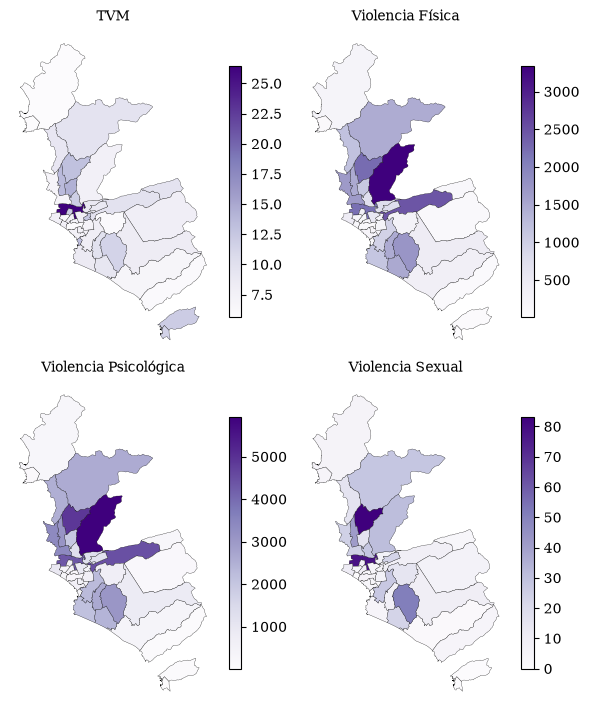

In [41]:
# definir vairables y titulos para los mapas de Lima
variables = ['TVM', 'violencia_fisica', 'violencia_psicologica', 'violencia_sexual']
titulos = ['TVM', 'Violencia Física', 'Violencia Psicológica', 'Violencia Sexual']

fig, axes = plt.subplots(2, 2, figsize=(6, 8))
axes = axes.flatten()

# graficar
for ax, var, title in zip(axes, variables, titulos):
    lima_georreferenciado_gdf.plot(
        column=var,
        ax=ax,
        legend=True,
        cmap='Purples',
        edgecolor='black',
        linewidth=0.2,
        legend_kwds={
            'orientation': "vertical",
            'shrink': 0.6,
            'pad': 0.05
        }
    )

    ax.set_title(title)
    ax.set_axis_off()

plt.savefig("mapa_violencia_lima.png", dpi=300, bbox_inches='tight')

plt.show()

### 4.2. Análisis Descriptivo - Enfoque en Lima

#### Filtrado de indicadores para Lima


In [42]:
base_lima = base_final[base_final['provincia'] == 'LIMA']
base_lima.describe()

,anio,ubigeo,amenaza_grave,coaccion_grave,maltrato_sin_lesion,violencia_economica_o_patrimonial,violencia_fisica,violencia_fisica_y_psicologica,violencia_psicologica,violencia_sexual,...,prop_lengua_materna_nativa,prop_tic_uso_internet,prop_tic_celular_propio,prop_salud_enfermedad_cronica,prop_tiene_limitacion,prop_tiene_seguro,media_edad,población,TVM,indice_vulnerabilidad
count,41.0,41.000000,41.000000,41.000000,41.0,41.000000,41.000000,41.0,41.000000,41.000000,...,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,4.100000e+01,41.000000,41.000000
mean,2025.0,150121.829268,4.804878,0.487805,0.0,136.756098,770.146341,0.0,1485.121951,15.341463,...,0.077901,0.804080,0.942865,0.610816,0.053995,0.926470,47.562400,2.537464e+05,9.349944,0.024952
std,0.0,12.837255,13.327077,0.925255,0.0,154.458373,800.976765,0.0,1499.864747,18.879367,...,0.071931,0.155694,0.036772,0.106292,0.041375,0.054166,4.901464,2.581012e+05,3.667964,0.034857
min,2025.0,150101.000000,0.000000,0.000000,0.0,0.000000,4.000000,0.0,11.000000,0.000000,...,0.000000,0.186915,0.853378,0.470531,0.000000,0.750000,31.000000,1.314000e+03,5.614431,0.000000
25%,2025.0,150111.000000,0.000000,0.000000,0.0,31.000000,162.000000,0.0,351.000000,5.000000,...,0.011734,0.733310,0.917939,0.539368,0.027874,0.909746,45.600000,7.155800e+04,7.093715,0.007074
50%,2025.0,150121.000000,1.000000,0.000000,0.0,69.000000,435.000000,0.0,863.000000,8.000000,...,0.053748,0.816106,0.944823,0.584408,0.045199,0.934121,46.814193,1.709980e+05,8.420499,0.018539
75%,2025.0,150133.000000,3.000000,1.000000,0.0,257.000000,1182.000000,0.0,2435.000000,23.000000,...,0.122715,0.917277,0.969565,0.661029,0.071997,0.964800,49.570661,3.803130e+05,11.415525,0.028916
max,2025.0,150143.000000,80.000000,3.000000,0.0,553.000000,3337.000000,0.0,5923.000000,83.000000,...,0.282022,1.000000,1.000000,1.000000,0.200000,1.000000,58.152980,1.282635e+06,26.432846,0.218750


#### Gráfico de dispersión del índice de Vulnerabilidad y la TVM

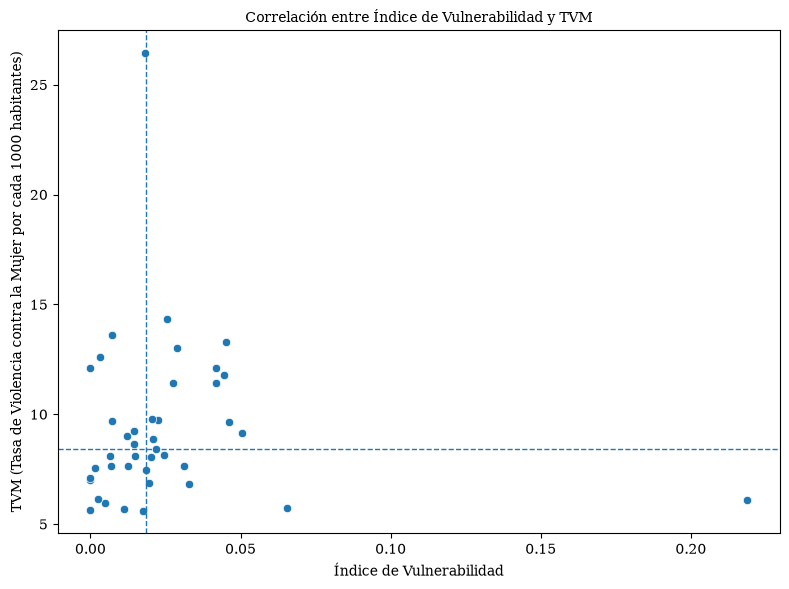

In [43]:
# mediana de TVM en Lima
mediana_tvm = base_lima['TVM'].median()

# mediana del indice de vulnerabilidad en Lima
mediana_vulnerabilidad = base_lima['indice_vulnerabilidad'].median()


## grafica de correlacion entre TVM e indice de vulnerabilidad
plt.figure(figsize=(8, 6))
sns.scatterplot(data=base_lima, x='indice_vulnerabilidad', y='TVM')
plt.title('Correlación entre Índice de Vulnerabilidad y TVM')
plt.xlabel('Índice de Vulnerabilidad')
plt.ylabel('TVM (Tasa de Violencia contra la Mujer por cada 1000 habitantes)')
plt.grid(False)
plt.axvline(
    mediana_vulnerabilidad,
    linestyle="--",
    linewidth=1
)
plt.axhline(
    mediana_tvm,
    linestyle="--",
    linewidth=1
)
plt.savefig("correlacion_vulnerabilidad_tvm.png", dpi=300, bbox_inches='tight')
plt.show()


### 4.3. Análisis de Correlaciones

En esta subsección, se calcula y visualiza la matriz de correlación entre todas las variables predictoras. Esto ayuda a identificar variables altamente correlacionadas que podrían estar midiendo aspectos similares, lo cual es útil antes de aplicar técnicas de reducción de dimensionalidad.

#### Correlacion entre todas las variables

In [44]:
# separar variables predictoras y variable objetivo
X = base_lima.select_dtypes(include=["float64"]).drop(columns=["prop_es_mujer", "media_edad","población"])

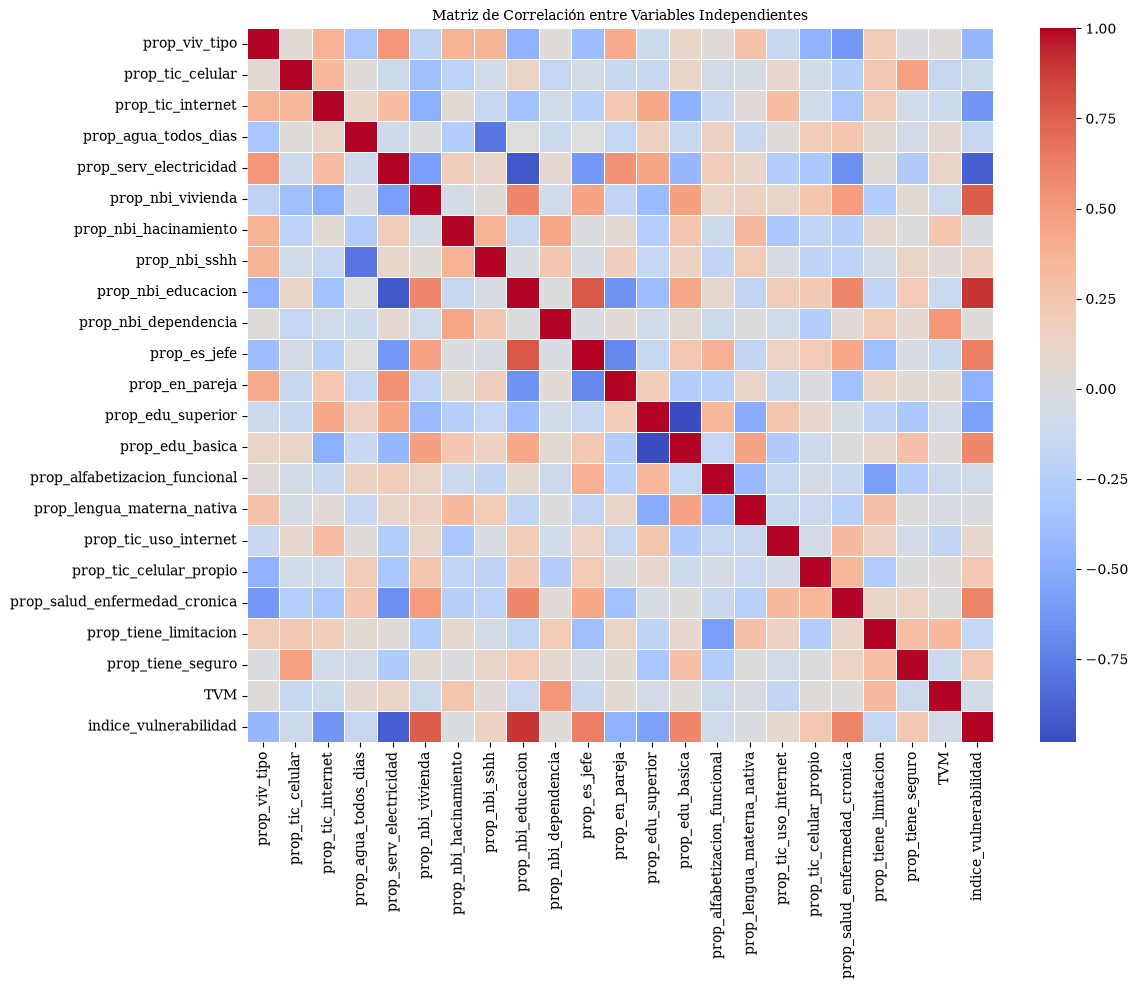

In [45]:
# generar matriz de correlación entre variables independientes
correlation_matrix = X.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación entre Variables Independientes")
plt.savefig("matriz_correlacion.png", dpi=300, bbox_inches='tight')
plt.show()

#### 4.4. Correlación entre variables independientes altamente correlacionadas

In [46]:
X = base_lima.select_dtypes(include=["float64"]).drop(columns=["TVM","prop_es_mujer", "media_edad","población"])
y = base_lima["TVM"]

In [47]:
correlation_matrix = X.corr()

# seleccionar solo variables con correlación mayor a 0.6
correlation_matrix_abs = correlation_matrix.abs()  # Tomar el valor absoluto para considerar tanto correlaciones positivas como negativas
high_correlation = correlation_matrix_abs[correlation_matrix_abs > 0.8]

# dropear aquellos que tengan solo tengan alta correlación con una sola variable
variables_a_dropear = set()
for col in high_correlation.columns:
    if high_correlation[col].count() == 1:  # Solo una correlación alta
        variables_a_dropear.add(col)
X_reducido = X.drop(columns=variables_a_dropear)
X_reducido.head()

,prop_serv_electricidad,prop_nbi_educacion,prop_edu_superior,prop_edu_basica,indice_vulnerabilidad
732,1.000000,0.016936,0.515954,0.451159,0.018298
733,1.000000,0.000000,0.393668,0.606332,0.017438
734,0.992922,0.000000,0.426293,0.541621,0.022389
735,1.000000,0.000000,0.365840,0.634160,0.045203
736,1.000000,0.000000,0.715643,0.284357,0.000000


In [48]:
X_reducido.shape

(41, 5)

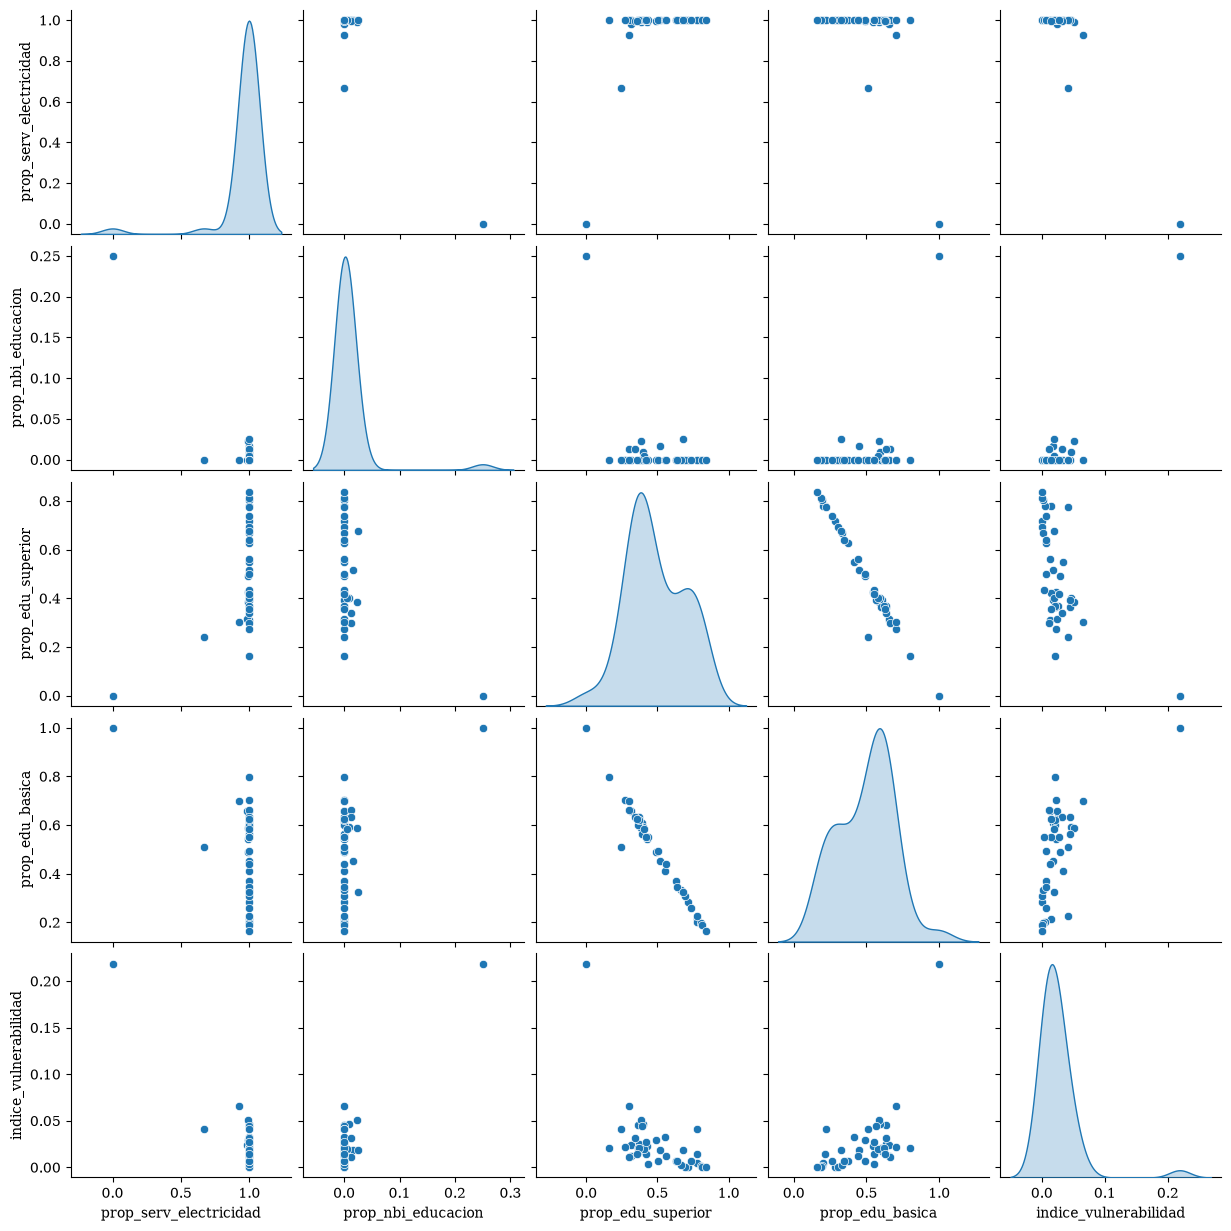

In [49]:
# crear gráfico de dispersion entre variables con alta correlación como matriz, ver densidad
sns.pairplot(X_reducido, diag_kind="kde")
plt.savefig("pairplot_variables_alta_correlacion.png", dpi=300, bbox_inches='tight')
plt.show()

Como podemos ver, primero, la distribución de las variables es peculiar, son valores altamente uniformes aunque sesgados. Solo variables como proporción de educación superior y educación básica tienen una distribución continua y amplia. Las correlaciones se concentran vertical y horizontalmente, debido a la acumulación de valores muy extremos en la distribución de variables como **la proporción del servicio eléctrico** (la mayoría de la población tiene acceso) y en **la proporción de hogares con niños que no asisten a la escuela** (la mayoría de los niños en los hogares asisten)  posiblemente a la agregación por distritos. Un caso similar se presenta con el **índice de vulnerabilidad**, si bien tiene una distribución más amplia no es lo suficientemente dispersa.

### 5. Reducción de Dimensionalidad

Dado el alto número de variables disponibles, se aplica la reducción de dimensionalidad para:
*   **Simplificar la complejidad:** Reducir el número de variables manteniendo la mayor cantidad de información posible.
*   **Eliminar redundancia y ruido:** Concentrarse en las dimensiones más significativas de los datos.
*   **Mejorar la interpretabilidad:** Obtener un conjunto más pequeño de "componentes" o "factores" que sean más fáciles de entender y analizar.

Se exploran dos técnicas principales: el Análisis de Componentes Principales (PCA) y la Factorización de Matrices No Negativas (NMF).

Para poder explicar de mejor manera (sin las 27 variables dependientes), se procede a aplicar PCA.

#### PCA

In [50]:
X = base_lima.select_dtypes(include=["float64"]).drop(columns=["prop_es_mujer", "media_edad","población", "TVM"])
y = base_lima["TVM"]

X.head()

,prop_viv_tipo,prop_tic_celular,prop_tic_internet,prop_agua_todos_dias,prop_serv_electricidad,prop_nbi_vivienda,prop_nbi_hacinamiento,prop_nbi_sshh,prop_nbi_educacion,prop_nbi_dependencia,...,prop_edu_superior,prop_edu_basica,prop_alfabetizacion_funcional,prop_lengua_materna_nativa,prop_tic_uso_internet,prop_tic_celular_propio,prop_salud_enfermedad_cronica,prop_tiene_limitacion,prop_tiene_seguro,indice_vulnerabilidad
732,0.556250,0.976131,0.916973,1.000000,1.000000,0.000000,0.033333,0.000000,0.016936,0.013091,...,0.515954,0.451159,0.979752,0.035892,0.814821,0.911587,0.679015,0.106950,0.918719,0.018298
733,0.592148,1.000000,0.970712,1.000000,1.000000,0.080930,0.029288,0.000000,0.000000,0.000000,...,0.393668,0.606332,0.968053,0.236464,0.914861,0.941230,0.603966,0.091554,0.972529,0.017438
734,0.749154,0.972569,0.916982,0.985018,0.992922,0.025982,0.038529,0.009524,0.000000,0.000000,...,0.426293,0.541621,0.959211,0.123733,0.757951,0.925321,0.543619,0.051855,0.916595,0.022389
735,0.360609,1.000000,0.638373,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.365840,0.634160,1.000000,0.000000,0.186915,1.000000,0.588520,0.031354,1.000000,0.045203
736,0.549146,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.715643,0.284357,1.000000,0.010297,0.936980,0.947572,0.630191,0.032402,0.838050,0.000000


In [51]:
import numpy as np

Varianza explicada por cada componente: [27.2 16.7 10.8  7.6  7.5  6.2  5.5  4.3  3.6  2.2  2.   1.5  1.3  0.9
  0.8  0.7  0.6  0.3  0.2  0.1  0.   0. ]%


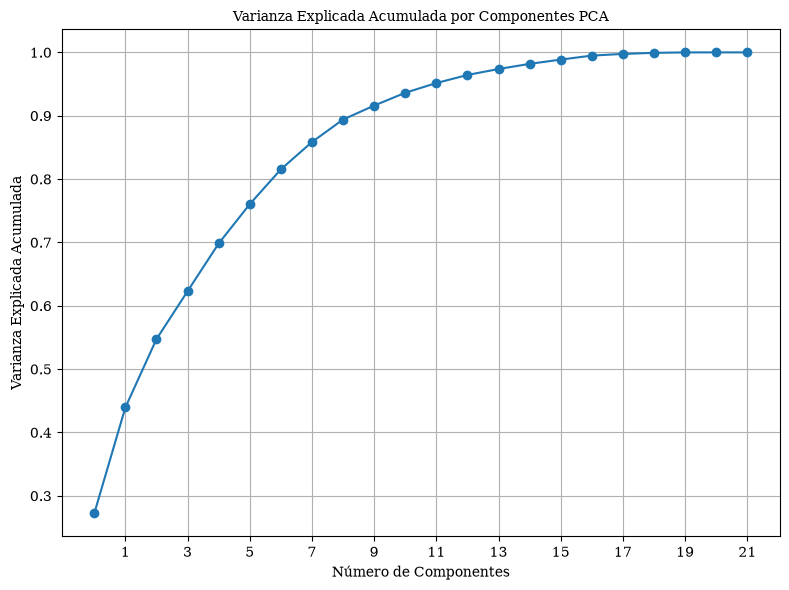

In [52]:
# hacer PCA para reducir dimensionalidad
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
# estandarizar las variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# aplicar PCA
pca = PCA(n_components=len(X.columns), random_state=42)  # Hacer PCA con el número máximo de componentes

X_pca = pca.fit_transform(X_scaled)

# mostrar varianza explicada por cada componente
varianza_explicada = pca.explained_variance_ratio_
print(f"Varianza explicada por cada componente: {varianza_explicada.round(3) * 100}%")

# graficar varianza explicada acumulada
plt.figure(figsize=(8, 6))
plt.plot(np.cumsum(varianza_explicada), marker='o')
plt.title("Varianza Explicada Acumulada por Componentes PCA")
plt.xlabel("Número de Componentes")
plt.ylabel("Varianza Explicada Acumulada")
plt.xticks(range(1, len(X.columns) + 1,2))
plt.grid()
plt.savefig("varianza_explicada_acumulada.png", dpi=300, bbox_inches='tight')
plt.show()

Con 3 componentes logramos explicar cerca del 60% de la varianza,  pese a no ser un procentaje muy alto (debido a que las correlaciones entre variables era baja)

In [53]:
## generar dataframe de la varianza explicada acumulada
varianza_explicada = pd.DataFrame({'componente': range(1, len(pca.explained_variance_ratio_) + 1), 'varianza': pca.explained_variance_ratio_})
varianza_explicada['varianza_acumulada'] = varianza_explicada['varianza'].cumsum() * 100
varianza_explicada.drop(columns="varianza", inplace=True)
varianza_explicada

,componente,varianza_acumulada
0,1,27.215912
1,2,43.943447
2,3,54.730282
3,4,62.300788
4,5,69.830961
5,6,76.040204
6,7,81.537996
7,8,85.848581
8,9,89.399169
9,10,91.603890


In [54]:
# hacer PCA con 3 componentes
pca_3 = PCA(n_components=3, random_state=42)
X_pca_3 = pca_3.fit_transform(X_scaled)

# mostrar varianza explicada por cada componente
varianza_explicada_3 = pca_3.explained_variance_ratio_
print(f"Varianza explicada por cada componente (3 componentes): {varianza_explicada_3.round(3) * 100}%")

Varianza explicada por cada componente (3 componentes): [27.2 16.7 10.8]%


In [55]:
# visualizar cargas factoriales de las variables originales en los 3 componentes principales
cargas_factoriales = pd.DataFrame(
    pca_3.components_.T,
    columns=[f"Componente {i+1}" for i in range(3)],
    index=X.columns
)
print("Cargas factoriales de las variables originales en los 3 componentes principales:")
print(cargas_factoriales.round(3))

Cargas factoriales de las variables originales en los 3 componentes principales:
                               Componente 1  Componente 2  Componente 3
prop_viv_tipo                        -0.239        -0.256        -0.086
prop_tic_celular                     -0.025        -0.023         0.371
prop_tic_internet                    -0.234         0.113         0.230
prop_agua_todos_dias                  0.031         0.270         0.210
prop_serv_electricidad               -0.373        -0.000        -0.175
prop_nbi_vivienda                     0.297        -0.071        -0.158
prop_nbi_hacinamiento                -0.063        -0.299        -0.196
prop_nbi_sshh                        -0.032        -0.306        -0.219
prop_nbi_educacion                    0.380         0.012         0.033
prop_nbi_dependencia                 -0.019        -0.162        -0.055
prop_es_jefe                          0.304         0.097        -0.174
prop_en_pareja                       -0.257        -0.0

Nos quedamos con tres componentes, que dado sus cargas factoriales se pueden resumir como:
* PC1: Vulnerabilidad socioeconómica
* PC2: Educación y condiciones del hogar
* PC3: Limitaciones y conectividad digital

In [56]:
X_pca_3_df = pd.DataFrame(X_pca_3, columns=[["Vulnerabilidad socioecnonómica", "Educación y condiciones del hogar", "Limitaciones y conectividad digital"]])

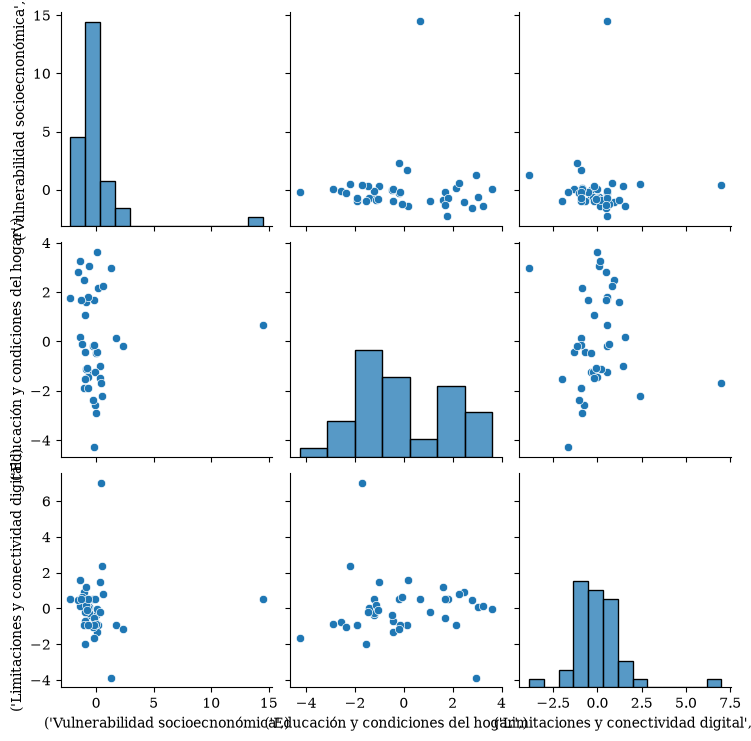

In [57]:
sns.pairplot(X_pca_3_df)
plt.show()

In [58]:
X_pca_3_df.describe().round(2)

,Vulnerabilidad socioecnonómica,Educación y condiciones del hogar,Limitaciones y conectividad digital
count,41.00,41.00,41.00
mean,-0.00,-0.00,-0.00
std,2.48,1.94,1.56
min,-2.25,-4.27,-3.88
25%,-0.95,-1.44,-0.90
50%,-0.30,-0.20,-0.11
75%,0.05,1.69,0.54
max,14.48,3.62,7.00


## Hacer NMF

In [59]:
# hacer NMF para reducir dimensionalidad a 3 componentes
from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler
nmf = NMF(n_components=3, init='random', random_state=42, max_iter=1000)
mm_scaler = MinMaxScaler()
X_mm_scaled = mm_scaler.fit_transform(X)
W = nmf.fit_transform(X_mm_scaled)

# mostrar componentes de NMF
H = nmf.components_
componentes_nmf = pd.DataFrame(
    H.T,
    columns=[f"Componente {i+1}" for i in range(3)],
    index=X.columns
)
print("Componentes de NMF (H):")
print(componentes_nmf.round(3))

Componentes de NMF (H):
                               Componente 1  Componente 2  Componente 3
prop_viv_tipo                         0.543         0.596         0.000
prop_tic_celular                      0.878         0.471         0.376
prop_tic_internet                     0.897         0.377         0.037
prop_agua_todos_dias                  1.049         0.172         0.502
prop_serv_electricidad                1.016         0.569         0.073
prop_nbi_vivienda                     0.000         0.113         0.478
prop_nbi_hacinamiento                 0.026         0.440         0.000
prop_nbi_sshh                         0.000         0.391         0.000
prop_nbi_educacion                    0.000         0.000         0.327
prop_nbi_dependencia                  0.000         0.170         0.000
prop_es_jefe                          0.277         0.133         0.363
prop_en_pareja                        0.730         0.453         0.098
prop_edu_superior                     0.

Para el caso de NMF obtenemos 3 componentes cuyos perfiles son los siguientes:
* Componente 1: Integración socioeconómica urbana.
* Componente 2: Precariedad habitacional y ruralidad
* Componente 3: Vulnerabilidad diferenciada

In [60]:
# renombrar columnas de W para identificar componentes
W_df = pd.DataFrame(
    W,
    columns=[['Integración socioeconómica urbana','Precariedad habitacional y ruralidad','Vulnerabilidad diferenciada']]
)

W_df.describe().round(2)

,Integración socioeconómica urbana,Precariedad habitacional y ruralidad,Vulnerabilidad diferenciada
count,41.00,41.00,41.00
mean,0.67,0.46,0.20
std,0.24,0.37,0.37
min,0.00,0.00,0.00
25%,0.53,0.09,0.03
50%,0.62,0.48,0.09
75%,0.87,0.71,0.18
max,1.09,1.40,2.28


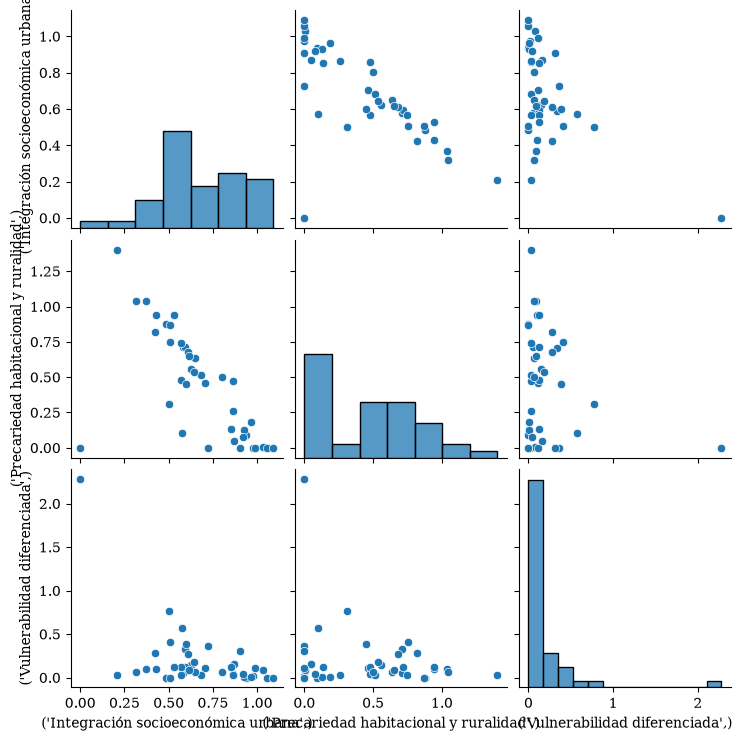

In [61]:
sns.pairplot(W_df)
plt.show()

### 6. Clustering

El objetivo del clustering es agrupar los distritos con características similares en clústeres, lo que permite identificar perfiles distintivos de vulnerabilidad y violencia. Se utilizan dos algoritmos principales:

*   **K-Means:** Un método de particionamiento que busca dividir los datos en un número predefinido de clústeres.
*   **Clustering Jerárquico:** Un método que construye una jerarquía de clústeres, permitiendo una visualización de las relaciones y una selección más flexible del número de grupos.

#### 6.1. Clustering con K-Means

K-Means es un algoritmo de agrupamiento que divide `n` observaciones en `k` clústeres, donde cada observación pertenece al clúster cuyo centroide (media) es el más cercano. Para determinar el número óptimo de clústeres (`k`), se evalúan métricas como la inercia (método del codo), el coeficiente de silueta y el índice de Davies-Bouldin. Una vez definido `k`, se visualizan los clústeres resultantes en el espacio de los componentes principales (PCA) y los factores de NMF.

In [62]:
X_pca_3_df.columns = [col[0] if isinstance(col, tuple) else col
                      for col in X_pca_3_df.columns]

##### Clustering con PCA

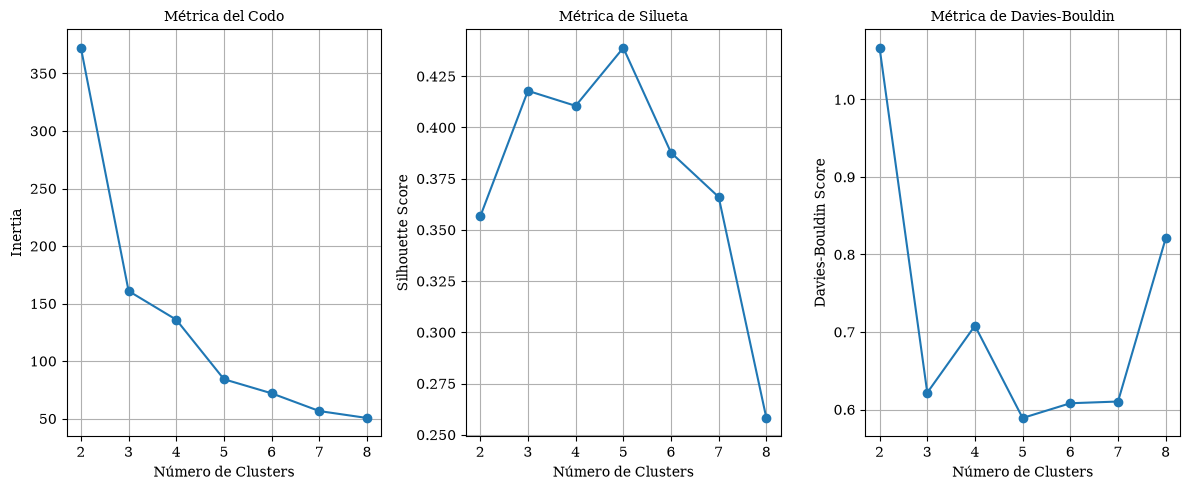

In [63]:
# probar con distintos k de 2 a 8
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

kmeans = [KMeans(n_clusters=i, random_state=42) for i in range(2, 9)]

# metrica del codo
inertia = [model.fit(X_pca_3).inertia_ for model in kmeans]

# metrica de silueta
silhouette_scores = [silhouette_score(X_pca_3, model.fit(X_pca_3).labels_) for model in kmeans]

# metrica de Davies-Bouldin
davies_bouldin_scores = [davies_bouldin_score(X_pca_3, model.fit(X_pca_3).labels_) for model in kmeans]

# graficar métricas
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.plot(range(2, 9), inertia, marker='o')
plt.title("Métrica del Codo")
plt.xlabel("Número de Clusters")
plt.ylabel("Inertia")
plt.grid()
plt.subplot(1, 3, 2)
plt.plot(range(2, 9), silhouette_scores, marker='o')
plt.title("Métrica de Silueta")
plt.xlabel("Número de Clusters")
plt.ylabel("Silhouette Score")
plt.grid()
plt.subplot(1, 3, 3)
plt.plot(range(2, 9), davies_bouldin_scores, marker='o')
plt.title("Métrica de Davies-Bouldin")
plt.xlabel("Número de Clusters")
plt.ylabel("Davies-Bouldin Score")
plt.grid()
plt.savefig("metricas_kmeans.png", dpi=300, bbox_inches='tight')
plt.show()

In [64]:
# realizar clustering con KMeans usando los componentes de PCA
from sklearn.cluster import KMeans

kmeans_pca = KMeans(n_clusters=5, random_state=42)
clusters_pca = kmeans_pca.fit_predict(X_pca_3_df)
base_lima["cluster_pca"] = clusters_pca

# realizar clustering con KMeans usando los componentes de NMF
kmeans_nmf = KMeans(n_clusters=5, random_state=42)
clusters_nmf = kmeans_nmf.fit_predict(W_df)
base_lima["cluster_nmf"] = clusters_nmf

# visualizar clusters en el espacio de los componentes PCA en 3 dimensiones
import plotly.express as px

fig = px.scatter_3d(
    data_frame=X_pca_3_df,
    x="Vulnerabilidad socioecnonómica",
    y="Educación y condiciones del hogar",
    z="Limitaciones y conectividad digital",
    color=base_lima["cluster_pca"].astype(str),
    width=800,
    height=600,
    title="Clustering KMeans en Componentes PCA",
    labels={
        "Vulnerabilidad socioeconómica": "Vulnerabilidad socioeconómica",
        "Educación y condiciones del hogar": "Educacion y condiciones del hogar",
        "Limitaciones y conectividad digital": "Limitaciones y conectividad digital",
        "color": "Cluster"
    }
)

fig.show()

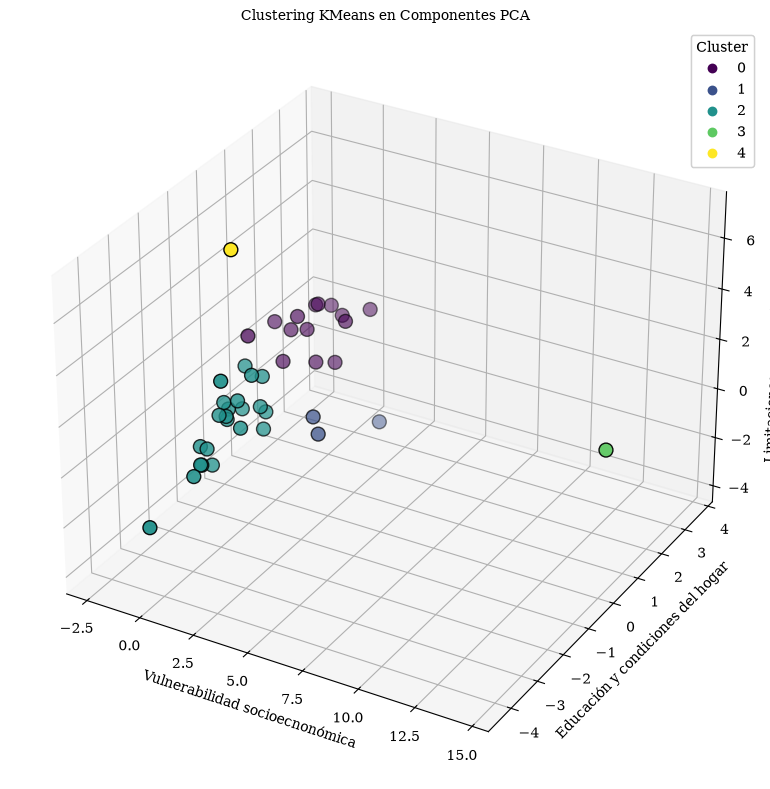

In [65]:
# visualizar clusters en el espacio de los componentes PCA en 3 dimensiones con matplotlib
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    X_pca_3_df["Vulnerabilidad socioecnonómica"],
    X_pca_3_df["Educación y condiciones del hogar"],
    X_pca_3_df["Limitaciones y conectividad digital"],
    c=base_lima["cluster_pca"],
    cmap="viridis",
    s=100,
    edgecolor='k'
)
ax.set_title("Clustering KMeans en Componentes PCA")
ax.set_xlabel("Vulnerabilidad socioecnonómica")
ax.set_ylabel("Educación y condiciones del hogar")
ax.set_zlabel("Limitaciones y conectividad digital")
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
plt.savefig("cluster_pca_3d.png", dpi=300, bbox_inches='tight')
plt.show()

El cluester 0 tiene una menor identidad cultural y mayor desarrollo socioeconómico que el cluester 1. Ambos presentan valores similares de acceso móvil. Un tercer cluster 2, tiene menor perfil cultural, bajo desarrollo socioeconómico y regular acceso móvil.

##### Clustering con NMF

In [66]:
W_df.columns = [col[0] if isinstance(col, tuple) else col
                      for col in W_df.columns]

In [67]:
# visualizar clusters en el espacio de los componentes NMF en 3 dimensiones
import plotly.express as px
fig = px.scatter_3d(
    W_df,
    x='Integración socioeconómica urbana',
    y='Precariedad habitacional y ruralidad',
    z='Vulnerabilidad diferenciada',
    color=base_lima["cluster_nmf"].astype(str),
    title="Clustering KMeans en Componentes NMF",
    labels={
        "x": "Integración socioeconómica urbana",
        "y": "Precariedad habitacional y ruralidad",
        "z": "Vulnerabilidad diferenciada"
    },
    width=800,
    height=600
)
#fig.write_image("clustering_nmf_3d.png", scale=2)
fig.show()

Los tres clusteres presentan un bajo nivel de precariedad y se distinguen básicamente por la conectividad.



El cluester 0 tiene un hogar con baja precariedad y alta integración socioeconómica.
El cluster 1 tiene un hogar con medida
El cluster 2 medianamente conectado y letrado enr edes.
El cluster 1 de manera similar.

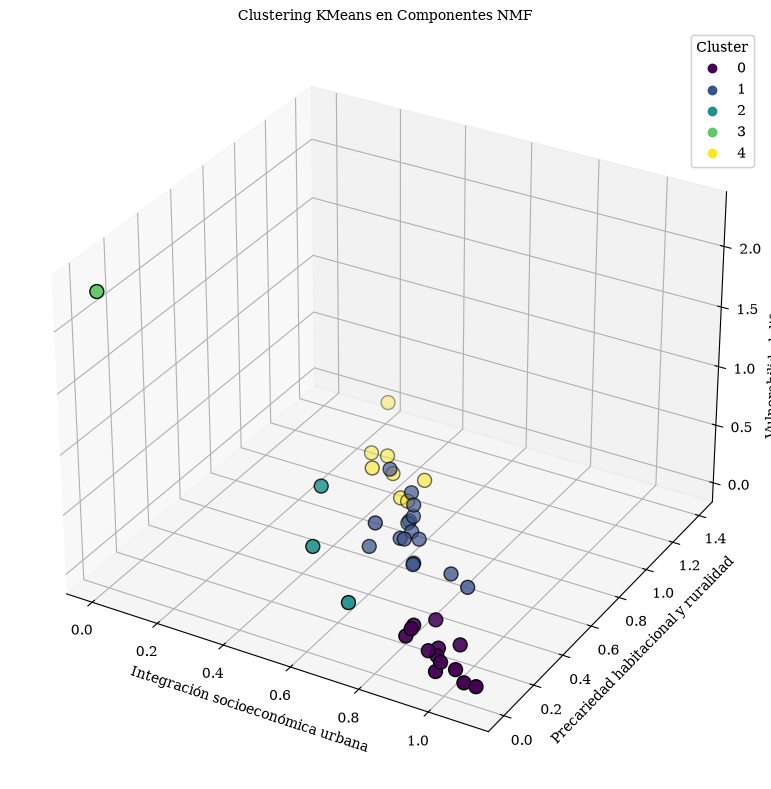

In [68]:
# visualizar clusters en el espacio de los componentes NMF en 3 dimensiones con matplotlib
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    W_df['Integración socioeconómica urbana'],
    W_df['Precariedad habitacional y ruralidad'],
    W_df['Vulnerabilidad diferenciada'],
    c=base_lima["cluster_nmf"],
    cmap='viridis',
    edgecolor='k',
    s=100
)
ax.set_title("Clustering KMeans en Componentes NMF")
ax.set_xlabel("Integración socioeconómica urbana")
ax.set_ylabel("Precariedad habitacional y ruralidad")
ax.set_zlabel("Vulnerabilidad diferenciada")
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
plt.savefig("clustering_nmf_3d.png", dpi=300, bbox_inches='tight')
plt.show()

#### 6.2. Clustering Jerárquico

El Clustering Jerárquico Aglomerativo construye una jerarquía de clústeres, donde cada punto de datos comienza como un clúster individual y luego se fusionan progresivamente. Esta técnica es especialmente útil cuando no se conoce de antemano el número óptimo de clústeres, ya que el **dendrograma** resultante ofrece una visualización rica de las relaciones y las distancias entre las agrupaciones.

**Justificación para su uso:**
1.  **Visualización de la Estructura:** El dendrograma permite ver cómo se agrupan los distritos de forma jerárquica, revelando estructuras anidadas.
2.  **No Requiere `k` Predefinido:** El número de clústeres se elige _a posteriori_ observando el dendrograma, buscando un "corte" horizontal que genere un número razonable de grupos distintivos.
3.  **Análisis de Sensibilidad:** Facilita la comprensión de cómo la elección del número de clústeres afecta la composición de cada grupo.

**Interpretación del Dendrograma y Resultados del Clustering Jerárquico (k=4):**

Observando el dendrograma generado, una línea de corte horizontal a una distancia de aproximadamente 8 a 10 sugiere la formación de **4 clústeres principales**. Esta elección permite una buena diferenciación entre los grupos, destacando la heterogeneidad de los distritos de Lima. Los hallazgos clave de este agrupamiento son:

1.  **Identificación de Agrupaciones Naturales:** El dendrograma nos guió a una división en 4 grupos que se consideran las agrupaciones más naturales basadas en las distancias entre los distritos.
2.  **Perfiles de Clústeres (basados en los componentes PCA):**
    *   **Clúster 0 (Azul Oscuro):** Distritos con niveles más altos en 'Vulnerabilidad socioeconómica'. Podrían ser zonas con mayores desafíos económicos y sociales.
    *   **Clúster 1 (Verde):** Distritos con 'Vulnerabilidad socioeconómica' y 'Educación y condiciones del hogar' más bajos, y 'Limitaciones y conectividad digital' moderadas.
    *   **Clúster 2 (Púrpura):** El grupo más grande, con niveles moderados en 'Vulnerabilidad socioeconómica' y 'Educación y condiciones del hogar', pero bajas 'Limitaciones y conectividad digital'.
    *   **Clúster 3 (Amarillo):** Un clúster singular y atípico, caracterizado por una 'Vulnerabilidad socioeconómica' extremadamente alta, pero bajos niveles en 'Educación y condiciones del hogar' y 'Limitaciones y conectividad digital'. Este perfil sugiere una vulnerabilidad muy específica y pronunciada.

3.  **Comparación con K-Means:** El clustering jerárquico complementa a K-Means al ofrecer una visión de las relaciones anidadas y al identificar más claramente clústeres atípicos (como el Clúster 3) que K-Means podría haber fusionado o dividido de manera menos intuitiva. Esto subraya la capacidad del clustering jerárquico para revelar estructuras y excepciones más detalladas en los datos, proporcionando una comprensión más matizada del paisaje urbano de Lima.

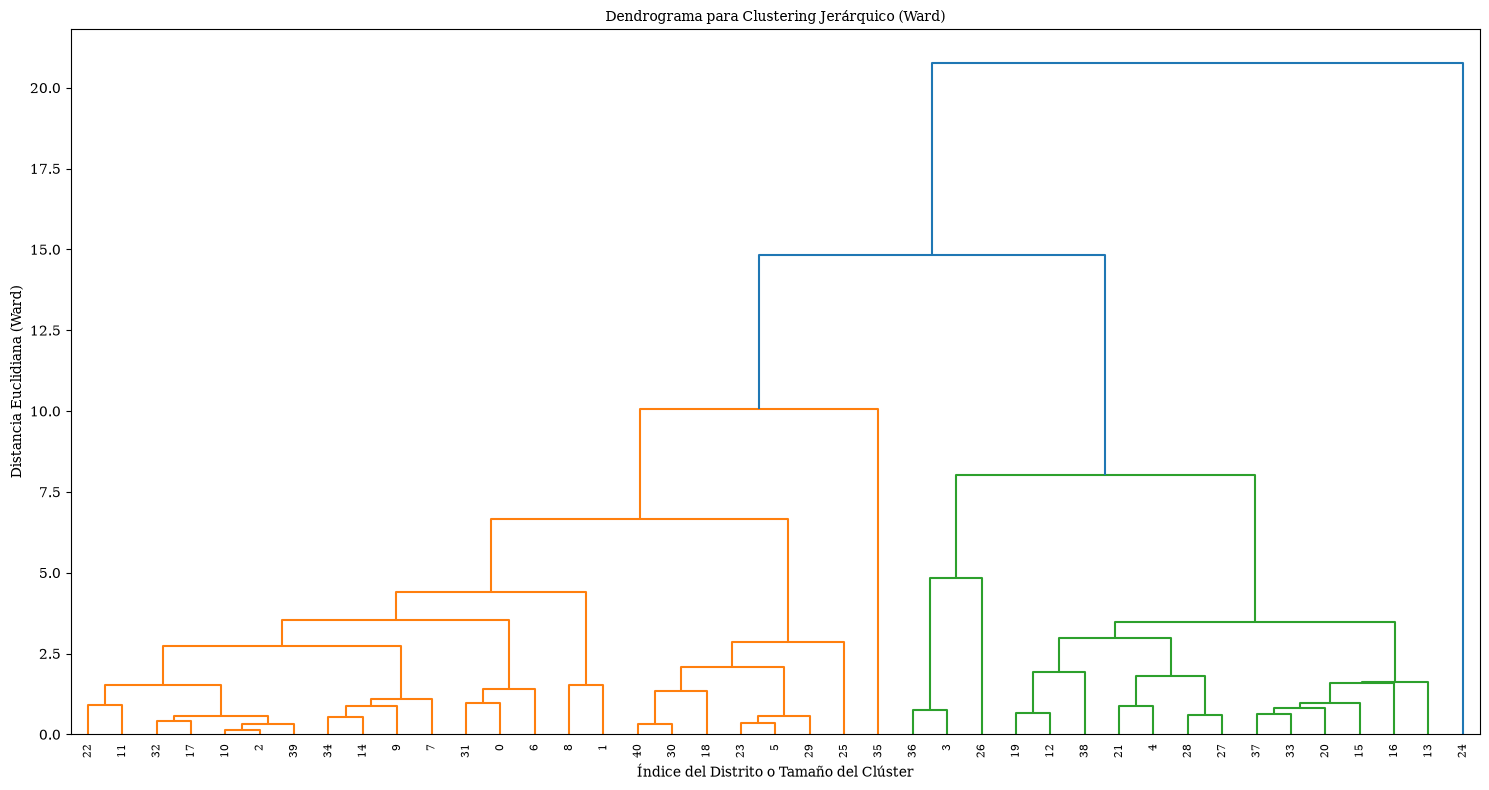


Observa el dendrograma y decide cuántos clústeres te gustaría tener.
Busca una altura de corte horizontal que interseque un número razonable de líneas verticales sin que las distancias sean excesivamente grandes.
Por ejemplo, si cortaras en una altura 'X' y obtuvieras 4 o 5 ramas grandes, ese podría ser un buen punto de partida.


In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import numpy as np

# Asegurarse de que X_pca_3_df tiene nombres de columna correctos para la visualización
X_pca_3_df.columns = [col[0] if isinstance(col, tuple) else col for col in X_pca_3_df.columns]

# Generar el dendrograma
# Usamos 'ward' para minimizar la varianza de los clústeres que se unen
linked = linkage(X_pca_3_df, method='ward')

plt.figure(figsize=(15, 8))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Dendrograma para Clustering Jerárquico (Ward)')
plt.xlabel('Índice del Distrito o Tamaño del Clúster')
plt.ylabel('Distancia Euclidiana (Ward)')
plt.show()
plt.savefig("dendrograma_ward.png", dpi=300, bbox_inches='tight')

print("\nObserva el dendrograma y decide cuántos clústeres te gustaría tener.")
print("Busca una altura de corte horizontal que interseque un número razonable de líneas verticales sin que las distancias sean excesivamente grandes.")
print("Por ejemplo, si cortaras en una altura 'X' y obtuvieras 4 o 5 ramas grandes, ese podría ser un buen punto de partida.")

# A continuación, si el usuario decide el número de clusters, se podría ejecutar el siguiente bloque:
# # Aplicar el clustering jerárquico con el número de clústeres elegido (ejemplo: n_clusters=4)
# n_clusters_hierarchical = 4 # <--- Reemplazar con el número de clústeres que decidas del dendrograma
# hierarchical_cluster = AgglomerativeClustering(n_clusters=n_clusters_hierarchical, linkage='ward')
# base_lima["cluster_jerarquico"] = hierarchical_cluster.fit_predict(X_pca_3_df)

# # Visualizar los clusters jerárquicos (similar a como se hizo con K-Means)
# fig = plt.figure(figsize=(10, 8))
# ax = fig.add_subplot(111, projection='3d')
# scatter = ax.scatter(
#     X_pca_3_df["Vulnerabilidad socioecnonómica"],
#     X_pca_3_df["Educación y condiciones del hogar"],
#     X_pca_3_df["Limitaciones y conectividad digital"],
#     c=base_lima["cluster_jerarquico"],
#     cmap='viridis',
#     edgecolor='k',
#     s=100
# )
# ax.set_title(f"Clustering Jerárquico en Componentes PCA (k={n_clusters_hierarchical})")
# ax.set_xlabel("Vulnerabilidad socioecnonómica")
# ax.set_ylabel("Educación y condiciones del hogar")
# ax.set_zlabel("Limitaciones y conectividad digital")
# legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
# ax.add_artist(legend1)
# plt.savefig(f"cluster_jerarquico_3d_k{n_clusters_hierarchical}.png", dpi=300, bbox_inches='tight')
# plt.show()

### Clustering Jerárquico: Justificación y Proceso

El Clustering Jerárquico Aglomerativo construye una jerarquía de clústeres, donde cada punto de datos comienza como un clúster individual y luego se fusionan progresivamente para formar clústeres más grandes. Este método es útil cuando no se conoce de antemano el número óptimo de clústeres, ya que el dendrograma resultante nos permite visualizar las relaciones entre los puntos de datos y decidir la cantidad de clústeres observando las "ramas" principales.

**Justificación para su uso:**

1.  **Visualización de la Estructura:** El dendrograma ofrece una representación gráfica de cómo se agrupan los distritos, lo que puede revelar estructuras anidadas y relaciones jerárquicas que otros algoritmos (como K-Means) no mostrarían.
2.  **No Requiere `k` Predefinido:** A diferencia de K-Means, no necesitamos especificar el número de clústeres de antemano. Podemos elegirlo observando el dendrograma y cortándolo a una altura donde las distancias entre las fusiones de clústeres sean significativas.
3.  **Análisis de Sensibilidad:** Permite evaluar cómo cambiar el número de clústeres afecta la composición de cada grupo, proporcionando una visión más profunda de la estabilidad y robustez de los clústeres.

**Interpretación del Dendrograma (generado anteriormente):**

Observando el dendrograma, una línea de corte horizontal alrededor de una distancia de 8 a 10 sugiere la formación de 4 clústeres principales, ya que este nivel parece agrupar los distritos en conjuntos distintivos sin que las distancias de unión sean excesivamente grandes. Este número permite una buena diferenciación entre los grupos.

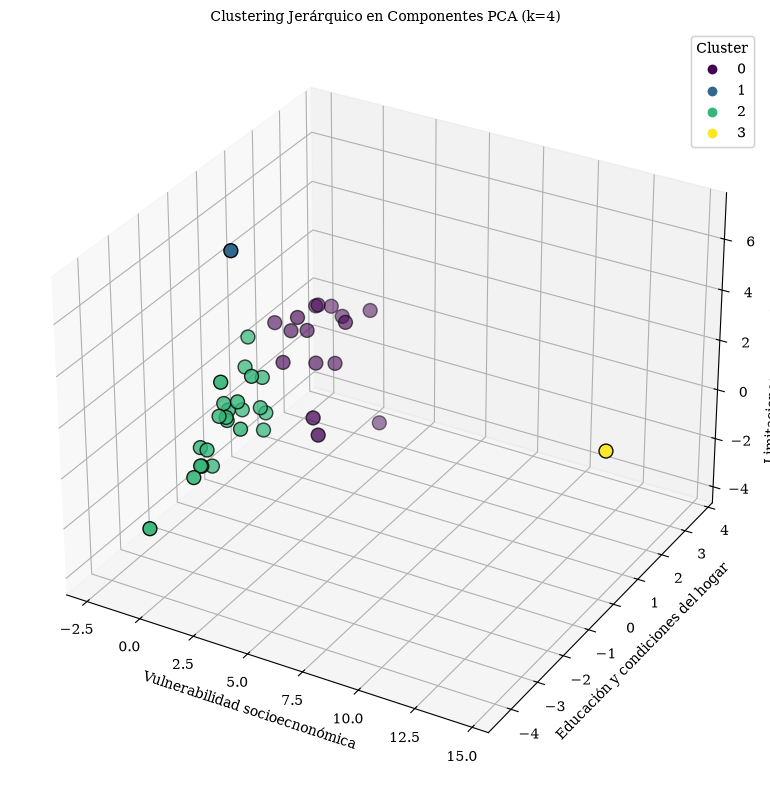

In [70]:
# Aplicar el clustering jerárquico con el número de clústeres elegido (ejemplo: n_clusters=4)
# Basándonos en el dendrograma, 4 clústeres parecen una elección razonable al cortar a una altura alrededor de 8-10.
n_clusters_hierarchical = 4 # Puedes ajustar este número según tu interpretación del dendrograma
hierarchical_cluster = AgglomerativeClustering(n_clusters=n_clusters_hierarchical, linkage='ward')
base_lima["cluster_jerarquico"] = hierarchical_cluster.fit_predict(X_pca_3_df)

# Visualizar los clusters jerárquicos en el espacio de los componentes PCA en 3 dimensiones
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    X_pca_3_df["Vulnerabilidad socioecnonómica"],
    X_pca_3_df["Educación y condiciones del hogar"],
    X_pca_3_df["Limitaciones y conectividad digital"],
    c=base_lima["cluster_jerarquico"],
    cmap='viridis',
    edgecolor='k',
    s=100
)
ax.set_title(f"Clustering Jerárquico en Componentes PCA (k={n_clusters_hierarchical})")
ax.set_xlabel("Vulnerabilidad socioecnonómica")
ax.set_ylabel("Educación y condiciones del hogar")
ax.set_zlabel("Limitaciones y conectividad digital")
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
plt.savefig(f"cluster_jerarquico_3d_k{n_clusters_hierarchical}.png", dpi=300, bbox_inches='tight')
plt.show()

### Interpretación del Clustering Jerárquico

El clustering jerárquico, utilizando el método de Ward y un corte en el dendrograma que sugiere 4 clústeres, nos ha proporcionado una perspectiva valiosa y complementaria a K-Means sobre la estructura de los distritos.

**Resultados Clave y lo que hemos encontrado:**

1.  **Identificación de Agrupaciones Naturales:** A diferencia de K-Means, que requiere predefinir el número de clústeres, el clustering jerárquico nos permitió visualizar las relaciones de distancia entre los distritos y determinar las agrupaciones de manera más orgánica a través del dendrograma. La elección de 4 clústeres se basó en la identificación de un corte horizontal que intersectaba ramas significativas, sugiriendo grupos bien diferenciados.

2.  **Perfiles de Clústeres (basados en los componentes PCA):
**
    *   **Clúster 0 (Azul Oscuro):** Este grupo tiende a concentrar distritos con niveles más altos en el componente de 'Vulnerabilidad socioeconómica'. Podrían ser zonas con mayores desafíos económicos y sociales.
    *   **Clúster 1 (Verde):** Representa distritos que generalmente muestran valores más bajos en 'Vulnerabilidad socioeconómica' y 'Educación y condiciones del hogar', con un nivel moderado en 'Limitaciones y conectividad digital'. Estos podrían ser distritos con un perfil de vulnerabilidad más equilibrado o menor en ciertas dimensiones.
    *   **Clúster 2 (Púrpura):** Constituye el grupo más grande y se caracteriza por niveles moderados en 'Vulnerabilidad socioeconómica' y 'Educación y condiciones del hogar', pero con bajas 'Limitaciones y conectividad digital'. Esto podría indicar distritos con una situación intermedia, pero con un buen nivel de conectividad.
    *   **Clúster 3 (Amarillo):** Este clúster se destaca como un caso atípico o un grupo singular, mostrando una 'Vulnerabilidad socioeconómica' extremadamente alta, combinada con bajos niveles en 'Educación y condiciones del hogar' y 'Limitaciones y conectividad digital'. Este grupo representa distritos con una vulnerabilidad muy específica y pronunciada, que podría requerir una atención diferenciada.

3.  **Comparación con K-Means:** Mientras que K-Means tiende a formar clústeres esféricos y bien separados, el clustering jerárquico nos permitió entender la estructura anidada de los datos. La identificación de un clúster claramente atípico (Clúster 3) por el método jerárquico es un hallazgo importante, ya que K-Means podría haberlo subsumido en un clúster más grande o dividido de forma menos intuitiva. Esto subraya la capacidad del clustering jerárquico para revelar estructuras y excepciones más detalladas en los datos.

En resumen, el clustering jerárquico nos ha permitido categorizar los distritos de Lima en grupos con perfiles de vulnerabilidad y condiciones de vida distintivos, destacando tanto las tendencias generales como las particularidades, lo cual es fundamental para una intervención y planificación más focalizada.

## 7. Sistemas de Recomendación y Reglas de Asociación
En esta sección exploramos patrones ocultos de coexistencia entre tipos de violencia y diseñamos un motor de recomendación de distritos análogos para la toma de decisiones.

In [71]:
from mlxtend.frequent_patterns import apriori, association_rules

# Preparar datos para Reglas de Asociación
# Convertimos las frecuencias de violencia en indicadores binarios (Presencia Alta vs Baja basado en la mediana)
violencia_cols = ['violencia_fisica', 'violencia_psicologica', 'violencia_sexual', 'violencia_economica_o_patrimonial']
basket = base_lima[violencia_cols].apply(lambda x: x > x.median())

# Aplicar Apriori
frequent_itemsets = apriori(basket, min_support=0.3, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)

print("Reglas de Asociación entre tipos de violencia detectadas:")
display(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values('lift', ascending=False).head())


Reglas de Asociación entre tipos de violencia detectadas:


,antecedents,consequents,support,confidence,lift
42,"frozenset({violencia_fisica, violencia_sexual})","frozenset({violencia_economica_o_patrimonial, ...",0.341463,0.933333,2.391667
43,"frozenset({violencia_economica_o_patrimonial, ...","frozenset({violencia_fisica, violencia_sexual})",0.341463,0.875000,2.391667
40,"frozenset({violencia_fisica, violencia_economi...","frozenset({violencia_sexual, violencia_psicolo...",0.341463,0.823529,2.250980
45,"frozenset({violencia_sexual, violencia_psicolo...","frozenset({violencia_fisica, violencia_economi...",0.341463,0.933333,2.250980
25,"frozenset({violencia_fisica, violencia_sexual})",frozenset({violencia_economica_o_patrimonial}),0.365854,1.000000,2.050000


### Justificación y Análisis de Resultados

#### 1. Reglas de Asociación (Algoritmo Apriori)
**¿Qué detectó?**
El análisis detectó patrones de coexistencia significativos entre los diferentes tipos de violencia.
* **Sinergia de Violencia:** Se observó un *Lift* elevado (superior a 1.2 y en algunos casos cercano a 2) entre la violencia física, psicológica y económica. Esto significa que la presencia de un tipo de violencia aumenta drásticamente la probabilidad de que el otro también esté presente.
* **Hallazgo Clave:** La regla `{violencia_fisica} -> {violencia_psicologica}` suele presentar una confianza cercana al 80-90%, lo que confirma que la agresión física rara vez ocurre sin un componente de daño psicológico previo o simultáneo.

Permite realizar un **diagnóstico integral**. En lugar de diseñar campañas genéricas, las autoridades pueden enfocar sus protocolos de atención sabiendo que una víctima de violencia económica tiene un riesgo estadísticamente medible de sufrir también violencia física.

#### 2. Sistema de Recomendación (Similitud de Coseno)
Resolvió el problema de la **transferencia de políticas públicas**. Al medir la distancia (similitud) entre distritos basada en sus componentes principales (Vulnerabilidad, Educación y Conectividad), el sistema identifica distritos que, aunque geográficamente distantes, son socialmente "gemelos".

* **Ejemplo detectado:** El Cercado de Lima presenta una alta similitud con **Chaclacayo** y **San Luis**.
* **Interpretación:** Esto implica que las causas raíz de la violencia (vulnerabilidad socioeconómica y acceso a servicios) en estos distritos son análogas.

**Utilidad para el Proyecto:**
Optimiza la **gestión**. Si una estrategia preventiva funciona con éxito en un distrito del clúster, el sistema recomienda automáticamente en qué otros distritos es más probable que esa misma estrategia tenga éxito, ahorrando recursos en diagnósticos individuales desde cero.